In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import random
#import itertools
#import sympy as sp

import gamelab.finitegames as nfg
import gamelab.symplecticFTRL
import gamelab.choice
import aspera.utils

In [3]:
primal_letter = 'x'
dual_letter = 'y'
quot_letter = 'z'

## Utils

In [4]:
# switch between coords and points
#def coords_points(L):

	#https://stackoverflow.com/questions/2921847/what-does-the-star-operator-mean-in-a-function-call
#	def make(*values):
#		return values

#	return make(*zip(*L))

# Symplectic FTRL on mixed extension of $[2 \times 2]$ normal form games

In [5]:
skeleton = [2, 2]

In [6]:
#BARE = nfg.NFG_bare(skeleton, "numeric", primal_letter)

## Games

In [7]:
# Matching pennies
payoff = [3, -3, -3, 3, -3, 3, 3, -3]
MP = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Matching Pennies', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

In [8]:
MP.payfield

[[3*x1_0 - 3*x1_1, -3*x1_0 + 3*x1_1], [-3*x0_0 + 3*x0_1, 3*x0_0 - 3*x0_1]]

In [9]:
MP.eff_payfield

[[12*x1_1 - 6], [6 - 12*x0_1]]

In [10]:
MP.quotpayfield

[array([0, -6*x1_0 + 6*x1_1], dtype=object),
 array([0, 6*x0_0 - 6*x0_1], dtype=object)]

In [11]:
MP.map_payfield.present()


V: X0 x X1(4) --> TY0 x TY1(4) 
 (x0_0, x0_1, x1_0, x1_1) --> (y'0_0, y'0_1, y'1_0, y'1_1) = [3*x1_0 - 3*x1_1, -3*x1_0 + 3*x1_1, -3*x0_0 + 3*x0_1, 3*x0_0 - 3*x0_1]


In [12]:
MP.map_quotpayfield.present()


v: X0 x X1(4) --> TZ0 x TZ1(4) 
 (x0_0, x0_1, x1_0, x1_1) --> (z'0_0, z'0_1, z'1_0, z'1_1) = [0, -6*x1_0 + 6*x1_1, 0, 6*x0_0 - 6*x0_1]


In [13]:
MP.map_eff_quotpayfield.present()


v: X0 x X1(2) --> TZ0 x TZ1(2) 
 (x0_1, x1_1) --> (z'0_1, z'1_1) = [12*x1_1 - 6, 6 - 12*x0_1]


In [14]:


# generalized harmonic
#payoff = [-1, -4, -3, -1, 1, 2, 2, -2] 
payoff = [27, -6, 3, -2, -17, 3, -1, -5]
GH = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Generalized Harmonic', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# prisoner's dilemma
payoff = [2, 0, 3, 1, 2, 3, 0, 1]
PD = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Prisoners Dilemma', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# split or steal
payoff = [5, 0, 10, 0, 5, 10, 0, 0]
SS = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Split or Steal', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# battle of sexes
payoff = [3, 0, 0, 2, 2, 0, 0, 3]
BS = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Battle of the Sexes', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# chicken
payoff = [-5, 2, 1, 0, -5, 1, 2, 0]
CH = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Chicken', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# coordination
payoff = [5, 1, 1, 4, 5, 1, 1, 4]
CO = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Coordination', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# anti-coordination
payoff = [1, 5, 4, 1, 1, 4, 5, 1]
ACO = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Anti-Coordination', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

# cyclic
payoff = [5, 1, 1, 4, -5, 1, 1, -4]
CY = nfg.NFG(skeleton = skeleton , strat_format = 'numeric', primal_letter = primal_letter, dual_letter = dual_letter, name = 'Cyclic', payoff_tensors =  nfg.Utils.u_flat_to_tensor(payoff, skeleton))

In [15]:
GAMES = [MP, GH, PD, SS, BS, CH, CO, ACO, CY]
#GAMES = [MP, GH, PD, CY]
#GAMES = [MP, GH, PD, CO]

## Vars

In [16]:
#primal_vars = BARE.primal_vars
#primal_vars

In [17]:
#dual_vars = BARE.make_vars(dual_letter, skeleton)
#dual_vars

In [18]:
#quot_vars = BARE.make_vars(quot_letter, skeleton)
#quot_vars

In [19]:
#BARE.make_vars_play(dual_letter, skeleton)

In [20]:
#BARE.make_packed(dual_letter, skeleton)

In [21]:
# LOGIT CHOICE
#sym_choice = [
#    sp.exp(dual_vars[0]) / ( sp.exp(dual_vars[0]) +  sp.exp(dual_vars[1])),
#    sp.exp(dual_vars[1]) / ( sp.exp(dual_vars[0]) +  sp.exp(dual_vars[1])),
#    sp.exp(dual_vars[2]) / ( sp.exp(dual_vars[2]) +  sp.exp(dual_vars[3])),
#    sp.exp(dual_vars[3]) / ( sp.exp(dual_vars[2]) +  sp.exp(dual_vars[3])),
#]

In [22]:
#logit = gamelab.choice.MultiLogit(primal_letter, dual_letter, skeleton)
#logit.Q.ex

# Z quotient

In [23]:
quotlogit = gamelab.choice.QuotientMultiLogit(primal_letter, dual_letter, skeleton, quot_letter)
quotlogit.Q.ex

Matrix([
[        1/(exp(z0_1) + 1)],
[exp(z0_1)/(exp(z0_1) + 1)],
[        1/(exp(z1_1) + 1)],
[exp(z1_1)/(exp(z1_1) + 1)]])

In [24]:
quotlogit.eff_Q.ex

Matrix([
[exp(z0_1)/(exp(z0_1) + 1)],
[exp(z1_1)/(exp(z1_1) + 1)]])

### Access primal and dual spaces either by primal space and dual space of MultiLogit instance, or domain and codomain of Map instance

In [25]:
#logit.primal_space.present()

In [26]:
#logit.Q.codomain.present()

In [27]:
#logit.dual_space.present()

In [28]:
#logit.Q.domain.present()

## Symplectic FTRL

In [29]:
#SFTRL_GAMES = [ gamelab.symplecticFTRL.SFTRL(game.map_payfield, logit.Q, primal_vars, dual_vars, game.name) for game in GAMES ]

In [30]:
#SFTRL_GAMES[0].choice( 1, 2, 3, 4 )

In [31]:
#SFTRL_GAMES[0].payfield(1, 2, 3, 4)

In [32]:
#SFTRL_GAMES[0].dVQ_VQ(1, 2, 3, 4)

## Z FTRL

In [33]:
#ZSFTRL_GAMES = [ gamelab.symplecticFTRL.ZSFTRL(game.map_quotpayfield, quotlogit.Q, primal_vars, quot_vars, game.name) for game in GAMES ]

In [34]:
#game = ZSFTRL_GAMES[0]

In [35]:
#game.map_VQ.present()

In [36]:
#game.sym_JQ

In [37]:
#game.VQ(1, 2, 3, 4)

## Effective Z SFTRL

In [38]:
eff_ZSFTRL_GAMES = [ gamelab.symplecticFTRL.ZSFTRL(game.map_eff_quotpayfield, quotlogit.eff_Q, quotlogit.eff_Q.codomain.vars, quotlogit.eff_Q.domain.vars, game.name) for game in GAMES ]

Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over
Init geometric version
pull done...
diff done...
product done...
Inverse done, Symbolic computations over


In [39]:
#eff_primal_vars = [_[0] for _ in GAMES[0].eff]
#eff_primal_vars

In [40]:
#lam_payfield = sp.lambdify(eff_primal_vars, [f[0] for f in GAMES[0].eff_payfield]   )

In [41]:
#lam_payfield(1, 1)

In [42]:
game = eff_ZSFTRL_GAMES[0]

In [43]:
game

In [44]:
game.map_choice.present()


q_0 x q_1: Z0 x Z1(2) --> X0 x X1(2) 
 (z0_1, z1_1) --> (x0_1, x1_1) = [exp(z0_1)/(exp(z0_1) + 1), exp(z1_1)/(exp(z1_1) + 1)]


In [45]:
game.map_choice.ex

Matrix([
[exp(z0_1)/(exp(z0_1) + 1)],
[exp(z1_1)/(exp(z1_1) + 1)]])

In [46]:
game.map_choice.inverse_ex

[(log(-x0_1/(x0_1 - 1)), log(-x1_1/(x1_1 - 1)))]

In [47]:
game.map_choice.inverse(*[0.6,0.5])

[(0.4054651081081642, 0.0)]

In [48]:
game.map_VQ.present()


v(q_0 x q_1): Z0 x Z1(2) --> TZ0 x TZ1(2) 
 (z0_1, z1_1) --> (z'0_1, z'1_1) = [6*tanh(z1_1/2), -6*tanh(z0_1/2)]


In [49]:
game.sym_JQ

Matrix([
[exp(z0_1)/(exp(z0_1) + 1) - exp(2*z0_1)/(exp(z0_1) + 1)**2,                                                          0],
[                                                         0, exp(z1_1)/(exp(z1_1) + 1) - exp(2*z1_1)/(exp(z1_1) + 1)**2]])

In [50]:
game.sym_JQ.inv()

Matrix([
[(exp(3*z0_1) + 3*exp(2*z0_1) + 3*exp(z0_1) + 1)/(exp(2*z0_1) + exp(z0_1)),                                                                         0],
[                                                                        0, (exp(3*z1_1) + 3*exp(2*z1_1) + 3*exp(z1_1) + 1)/(exp(2*z1_1) + exp(z1_1))]])

In [51]:
game.sym_symplectic_vfield

Matrix([
[36*((cosh(z0_1) + 1)*(exp(2*z1_1) + 2*exp(z1_1) + 1)*exp(z0_1) + (cosh(z1_1) + 1)*(exp(2*z0_1) + 2*exp(z0_1) + 1)*exp(z1_1))*(exp(3*z0_1) + 3*exp(2*z0_1) + 3*exp(z0_1) + 1)*exp(-z0_1)*tanh(z0_1/2)/((exp(z0_1) + 1)*(cosh(z0_1) + 1)*(cosh(z1_1) + 1)*(exp(2*z0_1) + 2*exp(z0_1) + 1)*(exp(2*z1_1) + 2*exp(z1_1) + 1))],
[36*((cosh(z0_1) + 1)*(exp(2*z1_1) + 2*exp(z1_1) + 1)*exp(z0_1) + (cosh(z1_1) + 1)*(exp(2*z0_1) + 2*exp(z0_1) + 1)*exp(z1_1))*(exp(3*z1_1) + 3*exp(2*z1_1) + 3*exp(z1_1) + 1)*exp(-z1_1)*tanh(z1_1/2)/((exp(z1_1) + 1)*(cosh(z0_1) + 1)*(cosh(z1_1) + 1)*(exp(2*z0_1) + 2*exp(z0_1) + 1)*(exp(2*z1_1) + 2*exp(z1_1) + 1))]])

In [52]:
game.quot_vars

(z0_1, z1_1)

In [53]:
eff_ZSFTRL_GAMES[0].symplectic_vfield(2,3)

[4.954504325279733, 13.685005507953178]

In [54]:
eff_ZSFTRL_GAMES[0].dVQ_VQ(2,3)

[8.23455223868289, 9.78669612956452]

In [55]:
# check consistency
#ZSFTRL_GAMES[0].dVQ_VQ(0, 2, 0, 3)

# Riemannian Symplectic FTRL in space of payoff differences

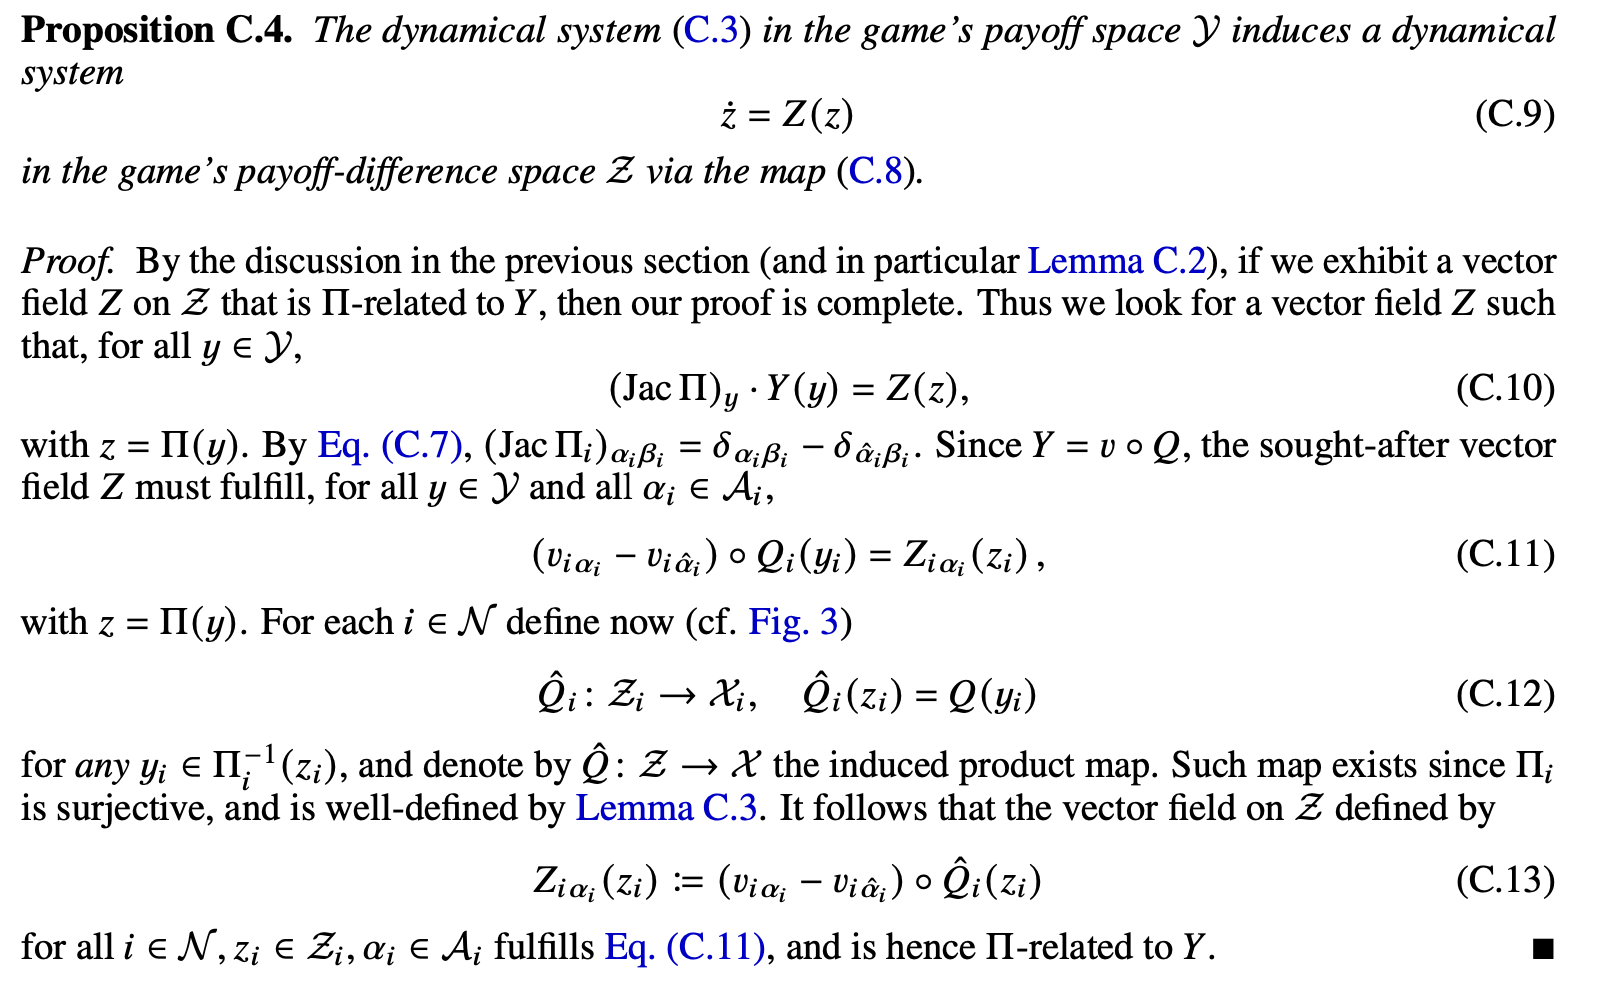

- Denote for simplicity by $V$ and $Q$ the respective objects in $Z$, i.e. $V = V_{.} - V_{.}$ and $Q$ descended to quotient

### FTRL: morally, pull-back and sharp!  $\dot{z} = [Q^{\ast}V]^{\sharp}  (z) = \text{Jac}Q^{-1}(z) \text{Jac}Q(z) \cdot V \circ Q(z)  =  V \circ Q(z)  $


### Pulled FTRL:  $\dot{z} = (Q^{\ast}V)(z) = \text{Jac}Q(z) \cdot V \circ Q(z)   $

## Symplectic corrections

---

- $\dot{z} = V \circ Q + \lambda [d(V \circ Q)] (V \circ Q)$ converges in spherical; "Euclidean"

---

### $\dot{z} = V \circ Q + \lambda \big[[d (Q^{\ast}V)](V \circ Q)\big]^{\sharp} $ converges in spherical "Riemannian V1"; using this in this file

---

- $\dot{z} = Q^{\ast}V(z) + \lambda \big[[d (Q^{\ast}V)](V \circ Q)\big]^{\sharp}$ geometrically not consistent but seems to convege very fast _[careful! May oscillate less, but also move slower]_ on spherical, slow on potential "Riemannian V2"

> The "pulled" or "Riemannian V2" version is geometrically not consistent, but not big deal; qualitatively, it behaves like the standard FTRL (in vanilla or symplectic or optimistic versions)
As a rule of thumb, it oscillates less and moves much slower than the standard FTRL version.
This means that in potential scenarios it converges much slower; in harmonic scenarios, it rotates much slower (vanilla) and converges slower but with less oscillation (optimistic - symplectic)

---

**Legendre for simplicity; everything goes to quotient**

 note that pull-back of $g$ via $Q$, that is metric in $Y$, _is_ $g^{-1}$
- $Q : Y \to X$
- $Q = \nabla h^{\ast} = (\nabla h)^{-1}$
- $JQ = \text{hess~}{h^{\ast}} = (\text{hess~}h)^{-1}$
- $g = \text{hess~}h = (JQ)^{-1}$
- $g^{-1} = JQ$
- $Q^{\ast}g = J^TQ \cdot g \cdot JQ = JQ \cdot (JQ)^{-1} \cdot JQ = g^{-1}$
- Hence sharping in $Y$ happens with $(Q^{\ast}g)^{-1} = g = (JQ)^{-1} $





In [56]:
game.map_choice.present()


q_0 x q_1: Z0 x Z1(2) --> X0 x X1(2) 
 (z0_1, z1_1) --> (x0_1, x1_1) = [exp(z0_1)/(exp(z0_1) + 1), exp(z1_1)/(exp(z1_1) + 1)]


In [57]:
game.choice( *(np.array([1,2]) * np.array([3,4])) )

[0.9525741268224333, 0.9996646498695335]

In [58]:
game.geom_sftrl_dyn( (1, 2), 'foo',  -0.1)

array([ 3.87088648, -4.92893733])

In [59]:
GAMES[0].eff_payfield

[[12*x1_1 - 6], [6 - 12*x0_1]]

In [60]:
GAMES[0].eff

[[x0_1], [x1_1]]

In [61]:
GAMES

In [62]:
import sympy as sp
lam_payfields = [ sp.lambdify( [ _[0] for _ in game.eff ], [ _[0] for _ in game.eff_payfield]  ) for game in GAMES ]

In [63]:
GAMES

In [64]:
eff_ZSFTRL_GAMES

In [65]:
lam_payfields

[<function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>,
 <function _lambdifygenerated(x0_1, x1_1)>]

## Ada FTRL+

In [66]:

def mirrori(y):
    return np.exp(y) / ( 1 + np.exp(y)  ) # entropic

# signal as convex combo of extra-gradient and optimistic
def make_signal(coef, v_curr, v_beforelead):
    return coef * v_curr + (1 - coef) * v_beforelead

def adaFTRLplus(y_1, nRuns, lam_payfield, eta_1 = np.ones(2) , v_half = np.zeros(2) , coef = 0.5 * np.ones(2) ):

    "y_1 = np.array([a, b])"
    
    x_1 = mirrori(eta_1 * y_1) # all players using same mirror
    

    v_1 = lam_payfield(*x_1)
    signal_1 = make_signal(coef, v_1, v_half) 
    t = 1

    y_curr = y_1
    eta_curr = eta_1

    x_curr = x_1
    v_curr = v_1
    signal_curr = signal_1

    y_lead = np.zeros(2)
    x_lead = np.zeros(2)
    v_lead = np.zeros(2)
    g_sum_curr = np.zeros(2)
    
    lead_sequence = []
    
    
    while t <= nRuns:

        y_lead = y_curr + signal_curr

        x_lead = mirrori( eta_curr * y_lead ) # all players same regularizers
        

        lead_sequence.append(x_lead)
        
        v_lead = lam_payfield(*x_lead)
        

        g_curr = v_lead - signal_curr
        
        
        g_sum_curr += g_curr * g_curr
        
        eta_next = (1 + g_sum_curr)**(-1/2)
        y_next = y_curr + v_lead

        x_next = mirrori( eta_next * y_next ) # all players using same regularizer
       


        v_next = lam_payfield(*x_next)
        signal_next = make_signal(coef, v_next, v_lead)
    
        t+=1

        y_curr = y_next
        eta_curr = eta_next
        signal_curr = signal_next
        
        
    x0 = [x[0] for x in lead_sequence]
    x1 = [x[1] for x in lead_sequence]

    return x0, x1

## ------------------------------------------------

## finite games $\to$ constrained setting & entropic regularizer

In [67]:
def plot_effZmethod_only_primal(ax1, quot_points, ftrl):
        primal_points = [ftrl.choice(*z) for z in quot_points]
    
        x01, x11 = aspera.utils.coords_points(primal_points) # primal coords

    
        ax1.plot(x01[-1], x11[-1], 'ro', label = 'final')
        ax1.plot(x01, x11, 'k')
        ax1.plot(x01[0], x11[0], 'bo', label = 'initial')
        
        ax1.set_xlim(-0.1,1.1)
        ax1.set_ylim(-0.1,1.1)

## Discrete symplectic adaptive FTRL

In [68]:
#LAM = -0.1
LAM = -1
#LAM = 0
#LAM = 0.1

In [69]:
# effective mirror map, entropic; ok for both all players using it and different players using different reg
def mirror(z, game):
    return game.choice(*z) # entropic

def oracle(z, game):
    return game.geom_sftrl_dyn( z, 'foo', LAM)

In [70]:
def Ada_SFTRL_step_size(z_1, nRuns, eta_1, game, eta_policy):

        "z_1 = np.array([a, b])"

        assert eta_policy in ["constant", "decreasing", "adaptive"]
        
        t = 1

        z_curr = z_1
        eta_curr = eta_1

        signal_sum = np.zeros(2)
        
        primal_sequence = []
        
        
        while t <= nRuns:

            x_curr = mirror(z_curr, game) # all players using same mirror               # step size
            #x_curr = mirror(eta_curr * z_curr, game) # all players using same mirror   # learn rate
            
            primal_sequence.append(x_curr)

            signal = oracle(z_curr, game)
            
            z_next = z_curr + eta_curr * signal # step size
            # z_next = z_curr + eta_curr        # learn rate
            

            if eta_policy == "adaptive":
                signal_sum += signal * signal
                eta_next = (1 + signal_sum)**(-1/2)
            
            if eta_policy == "constant":
                eta_next = eta_curr

            if eta_policy == "decreasing":
                eta_next = eta_curr / np.sqrt(t)
            
            
            
            t+=1

            z_curr = z_next
            eta_curr = eta_next
            
            
        x0 = [x[0] for x in primal_sequence]
        x1 = [x[1] for x in primal_sequence]

        return x0, x1

In [71]:
#NOT GOOD
def __OFF__Ada_SFTRL_learn_rate(z_1, nRuns, eta_1, game):

        "z_1 = np.array([a, b])"
        
        t = 1

        z_curr = z_1
        eta_curr = eta_1

        signal_sum = np.zeros(2)
        
        primal_sequence = []
        
        
        while t <= nRuns:

            #x_curr = mirror(           z_curr, game) # all players using same mirror               # step size
            x_curr = mirror(eta_curr * z_curr, game) # all players using same mirror               # learn rate
            
            primal_sequence.append(x_curr)

            signal = oracle(z_curr, game)

            #z_next = z_curr + eta_curr * signal        # step size
            z_next =  z_curr + signal                   # learn rate
            

            

            ## Adapt
            signal_sum += signal * signal
            eta_next = (1 + signal_sum)**(-1/2)
            

            # Constant
            #eta_next = eta_curr

            # sqrt(t)
            #eta_next = eta_curr / np.sqrt(t)



            
            
            
            t+=1

            z_curr = z_next
            eta_curr = eta_next
            
            
        x0 = [x[0] for x in primal_sequence]
        x1 = [x[1] for x in primal_sequence]

        return x0, x1

In [72]:

time = np.linspace(0, 10, 1000)

N_RUNS = 300
HORIZON = np.arange(N_RUNS)


num_orbits = 3

initial_dual_points = [[random.uniform(-3, 3) for _ in range(4)] for n in range(num_orbits)]
#initial_dual_points = [ [2, 2.5, 2.1, 2.4] ]

initial_quot_points = [nfg.Utils.flatten(nfg.Utils.quotient(nfg.Utils.pack( y, skeleton ))) for y in initial_dual_points]

initial_eff_quot_points = [nfg.Utils.flatten( [ z[1:] for z in nfg.Utils.quotient(nfg.Utils.pack( y, skeleton )) ] ) for y in initial_dual_points]

In [73]:
S_CONST_COLOR = "red"
S_ADA_COLOR = "green"
S_DEC_COLOR = "tab:purple"
EXTRA_ADA_COLOR = "blue"

## Run stuff

In [74]:
def norm(traj):
    return (np.array( traj[0] )**2 + np.array( traj[1] )**2)**(0.5)

<lambdifygenerated-49>:2: RuntimeWarning: overflow encountered in scalar multiply
  return [-16*(exp(z0_1) - 5)*((exp(z0_1) - 5)*(exp(z1_1) + 1)**2*exp(z0_1)*cosh((1/2)*z0_1)**2 + (exp(z0_1) + 1)**2*(exp(z1_1) - 6)*exp(z1_1)*cosh((1/2)*z1_1)**2 - (exp(z0_1) + 1)**2*(exp(z1_1) + 1)*exp(z1_1)*cosh((1/2)*z1_1)**2 - (exp(z0_1) + 1)*(exp(z1_1) + 1)**2*exp(z0_1)*cosh((1/2)*z0_1)**2)*(exp(3*z0_1) + 3*exp(2*z0_1) + 3*exp(z0_1) + 1)*exp(-z0_1)/((exp(z0_1) + 1)**4*(exp(z1_1) + 1)**2*(cosh(z0_1) + 1)*(cosh(z1_1) + 1)), -16*(exp(z1_1) - 6)*((exp(z0_1) - 5)*(exp(z1_1) + 1)**2*exp(z0_1)*cosh((1/2)*z0_1)**2 + (exp(z0_1) + 1)**2*(exp(z1_1) - 6)*exp(z1_1)*cosh((1/2)*z1_1)**2 - (exp(z0_1) + 1)**2*(exp(z1_1) + 1)*exp(z1_1)*cosh((1/2)*z1_1)**2 - (exp(z0_1) + 1)*(exp(z1_1) + 1)**2*exp(z0_1)*cosh((1/2)*z0_1)**2)*(exp(3*z1_1) + 3*exp(2*z1_1) + 3*exp(z1_1) + 1)*exp(-z1_1)/((exp(z0_1) + 1)**2*(exp(z1_1) + 1)**4*(cosh(z0_1) + 1)*(cosh(z1_1) + 1))]
<lambdifygenerated-49>:2: RuntimeWarning: invalid value encounte

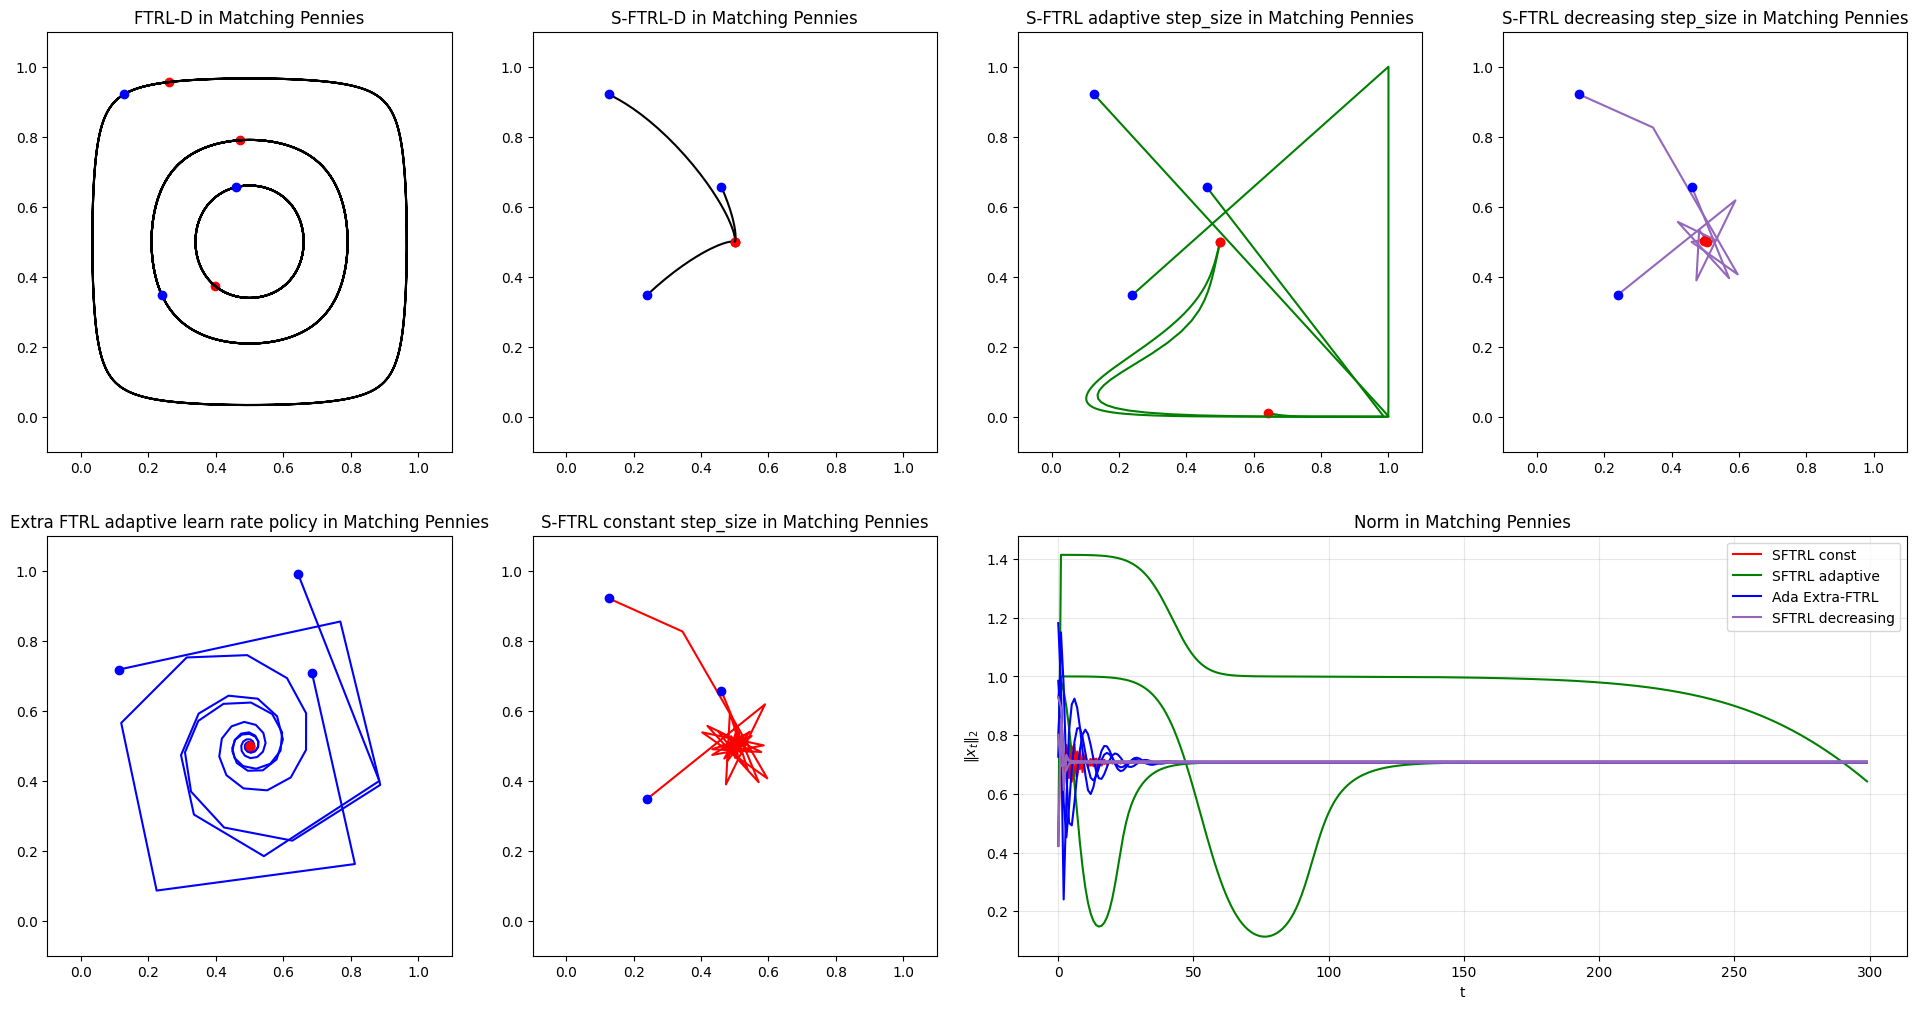

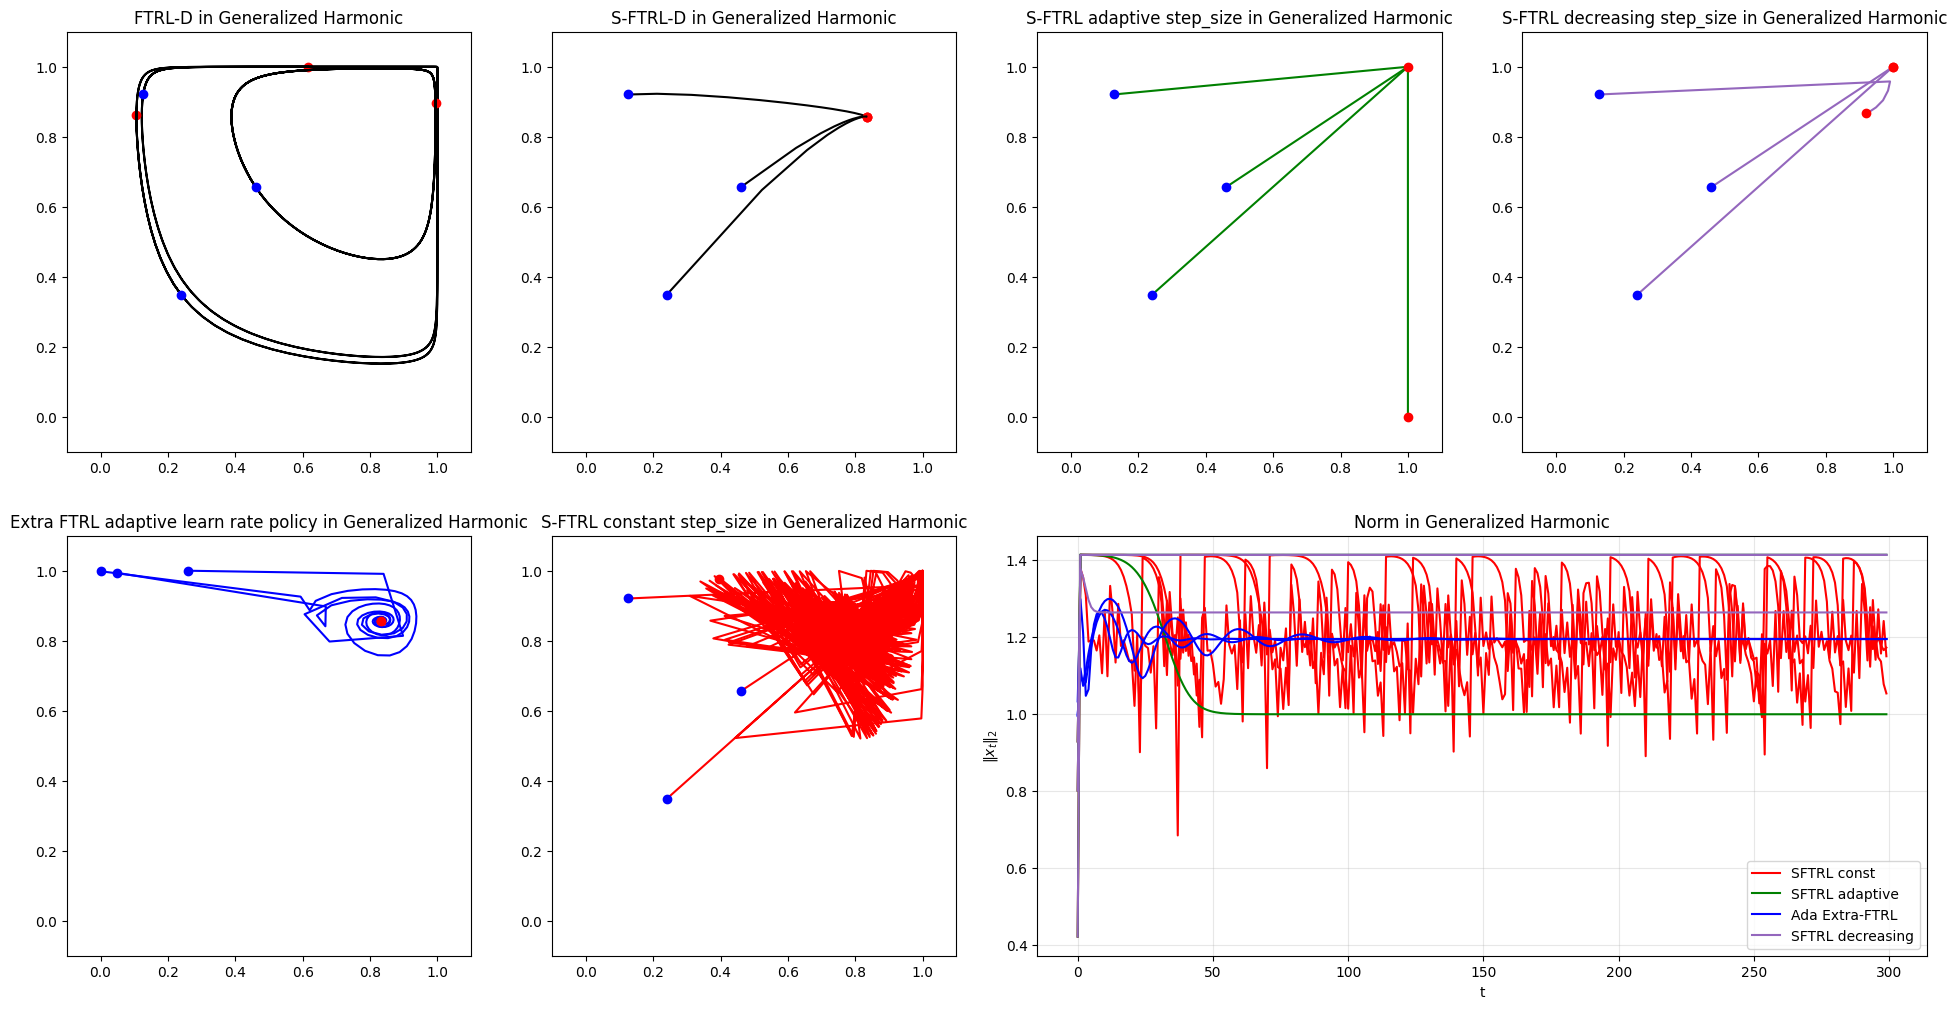

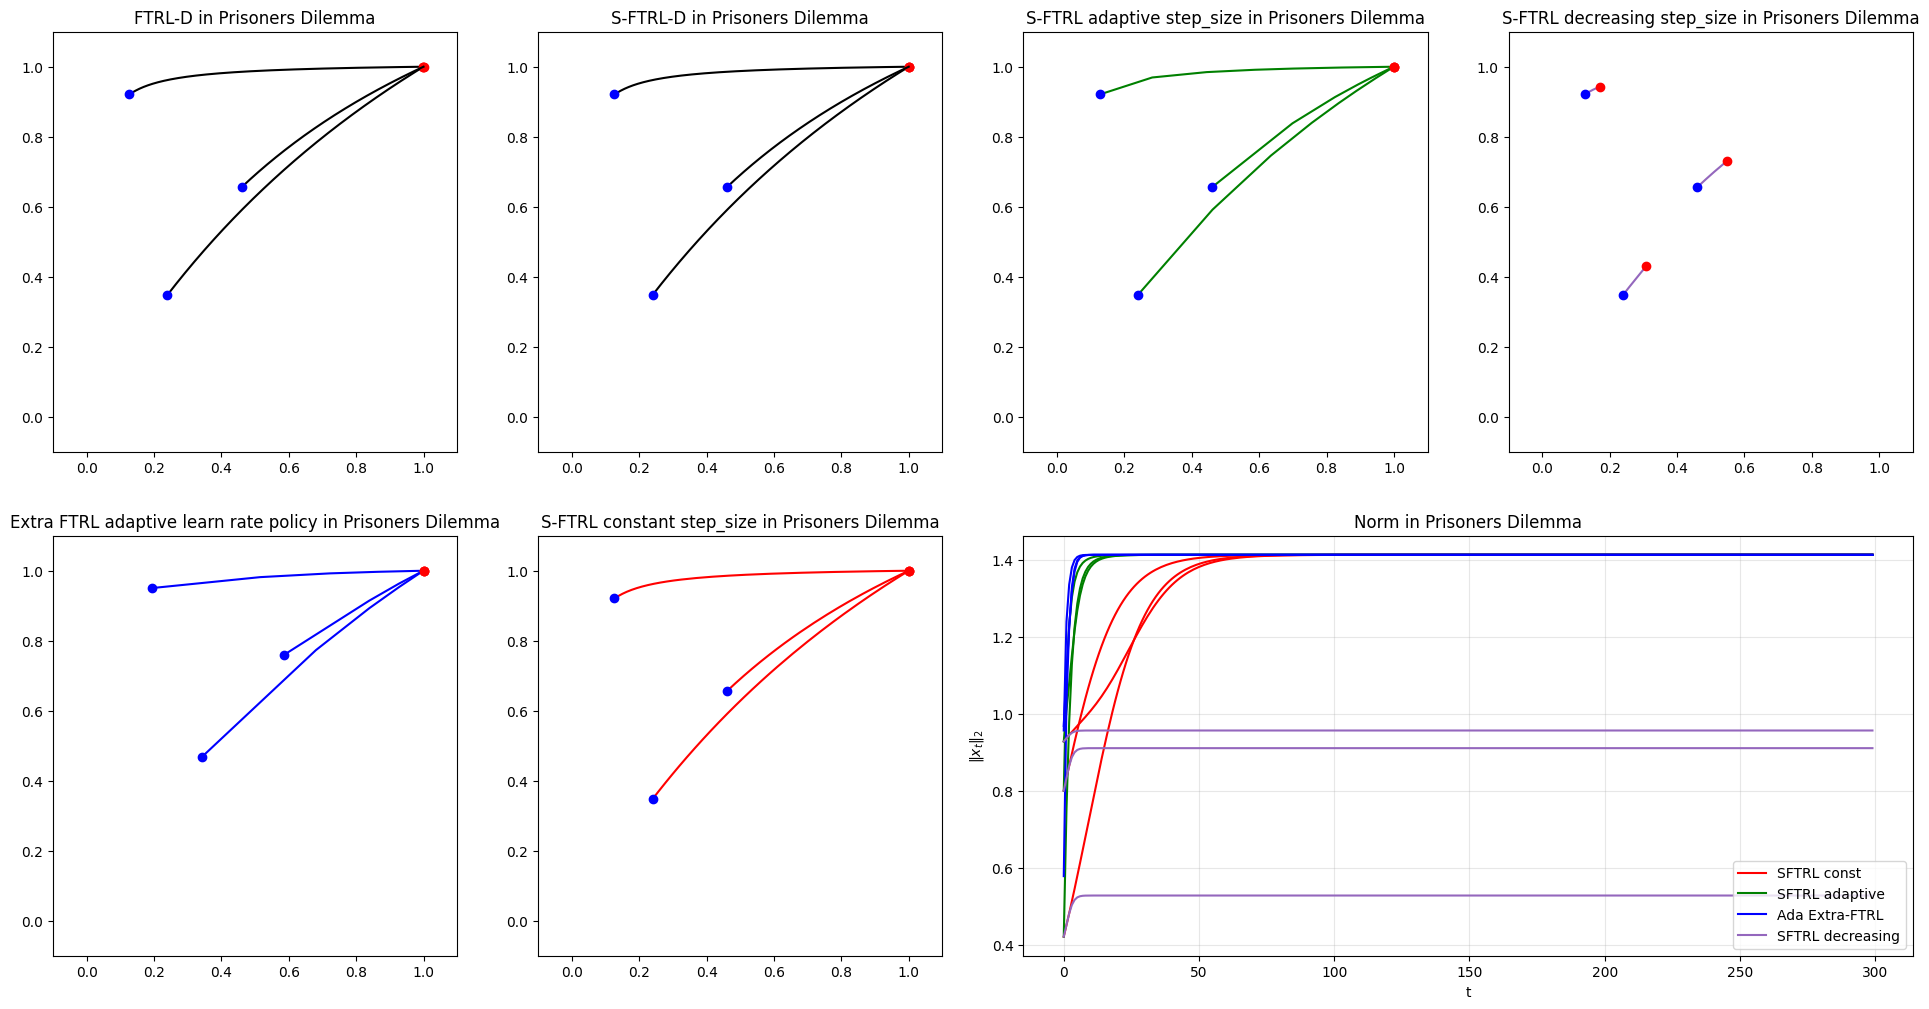

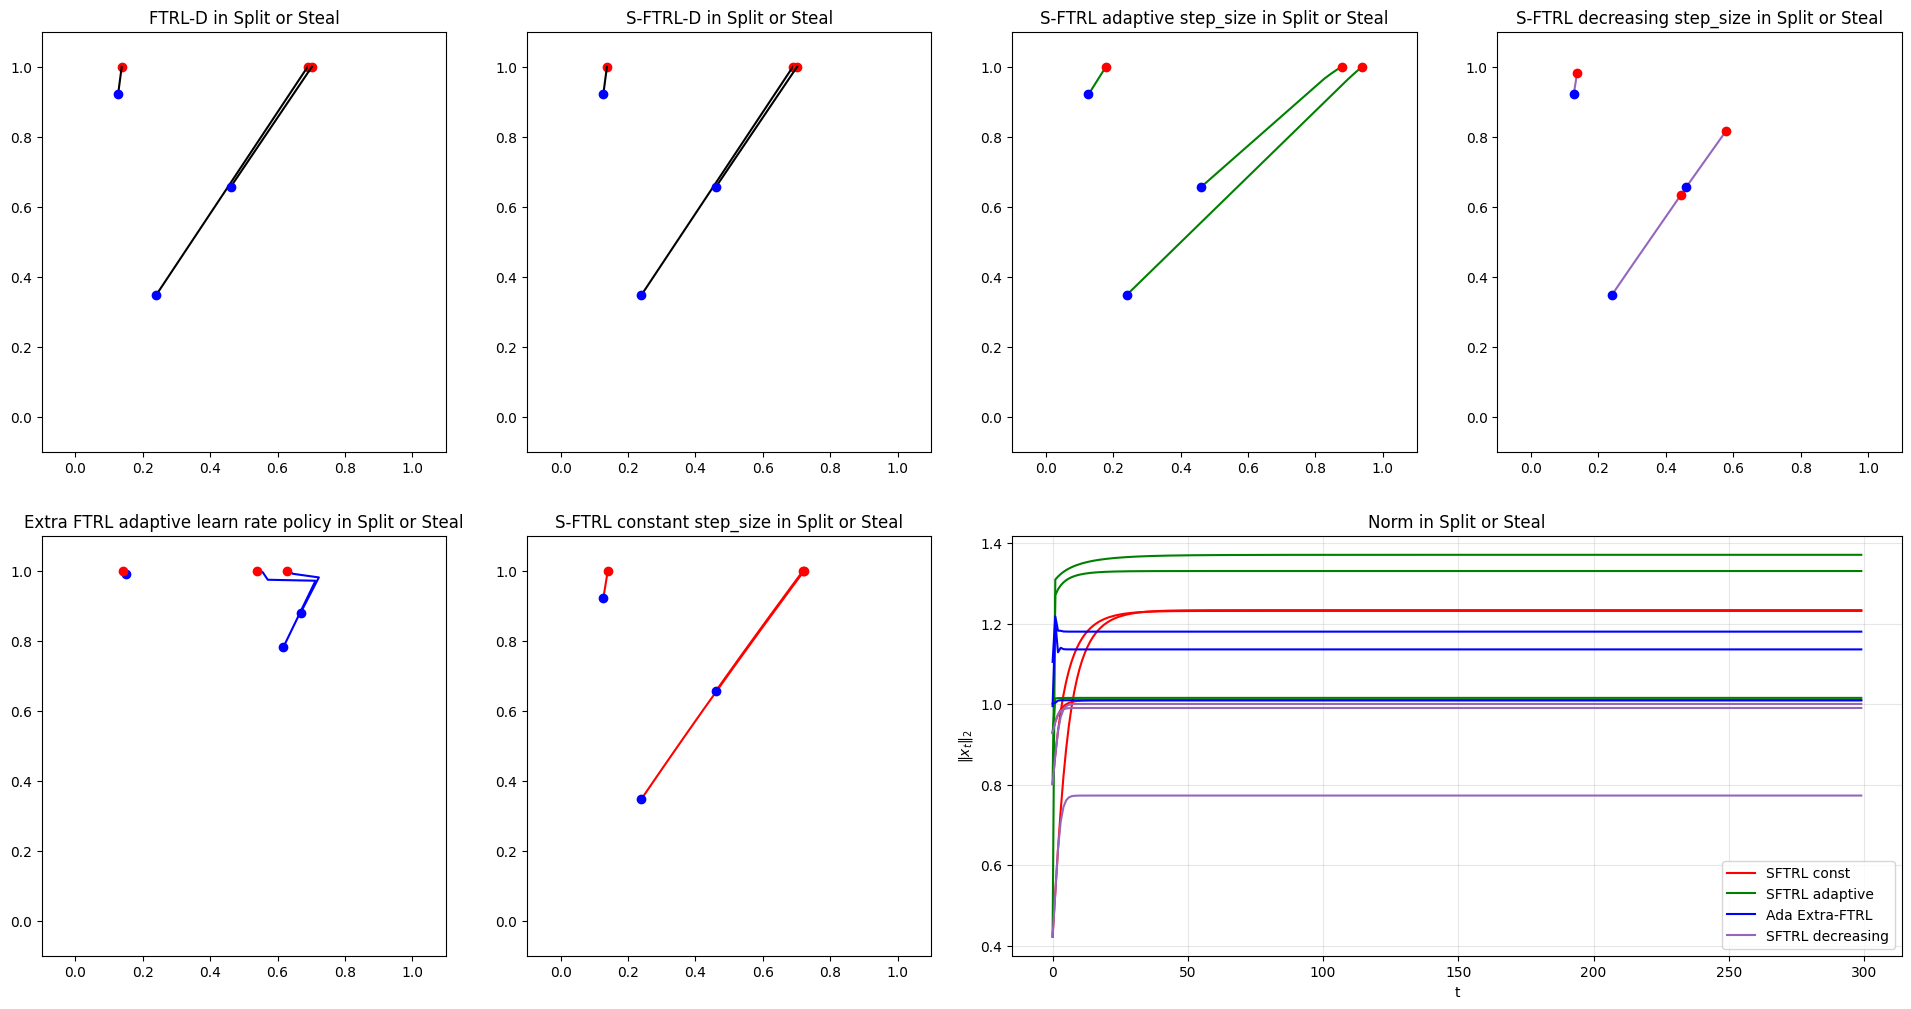

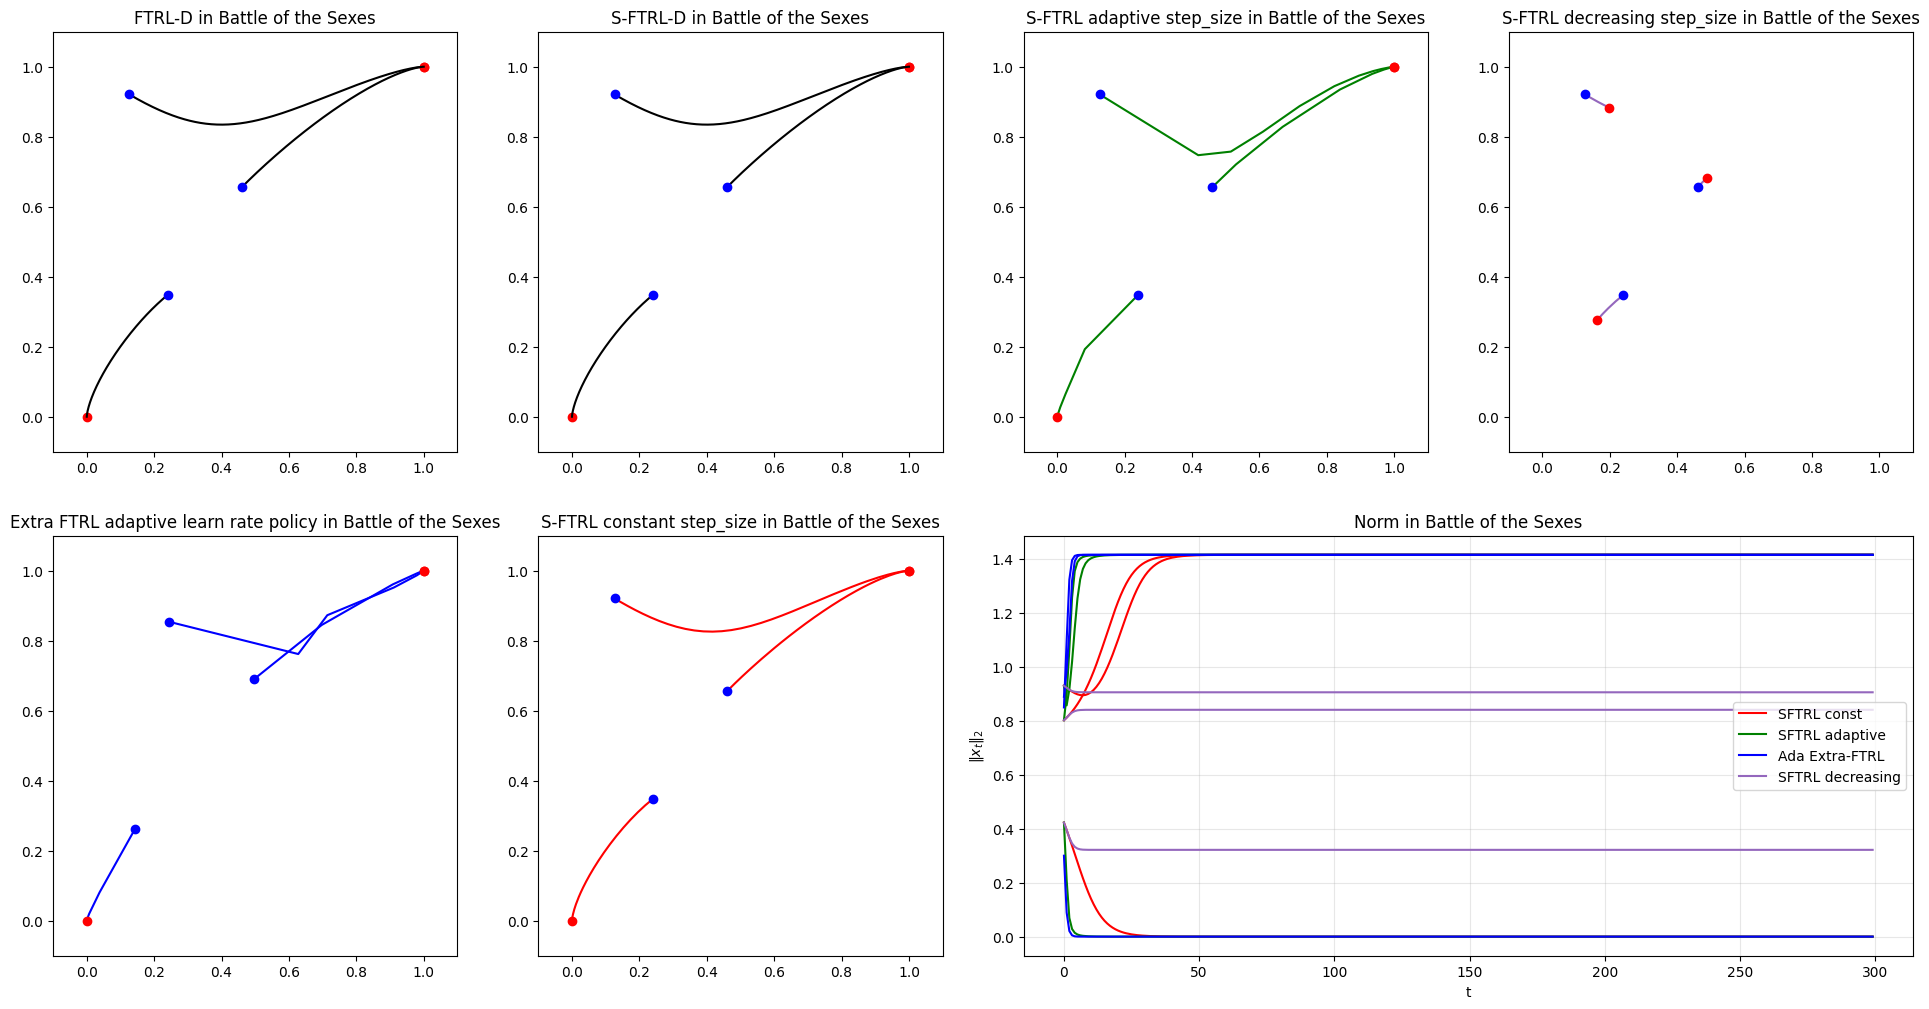

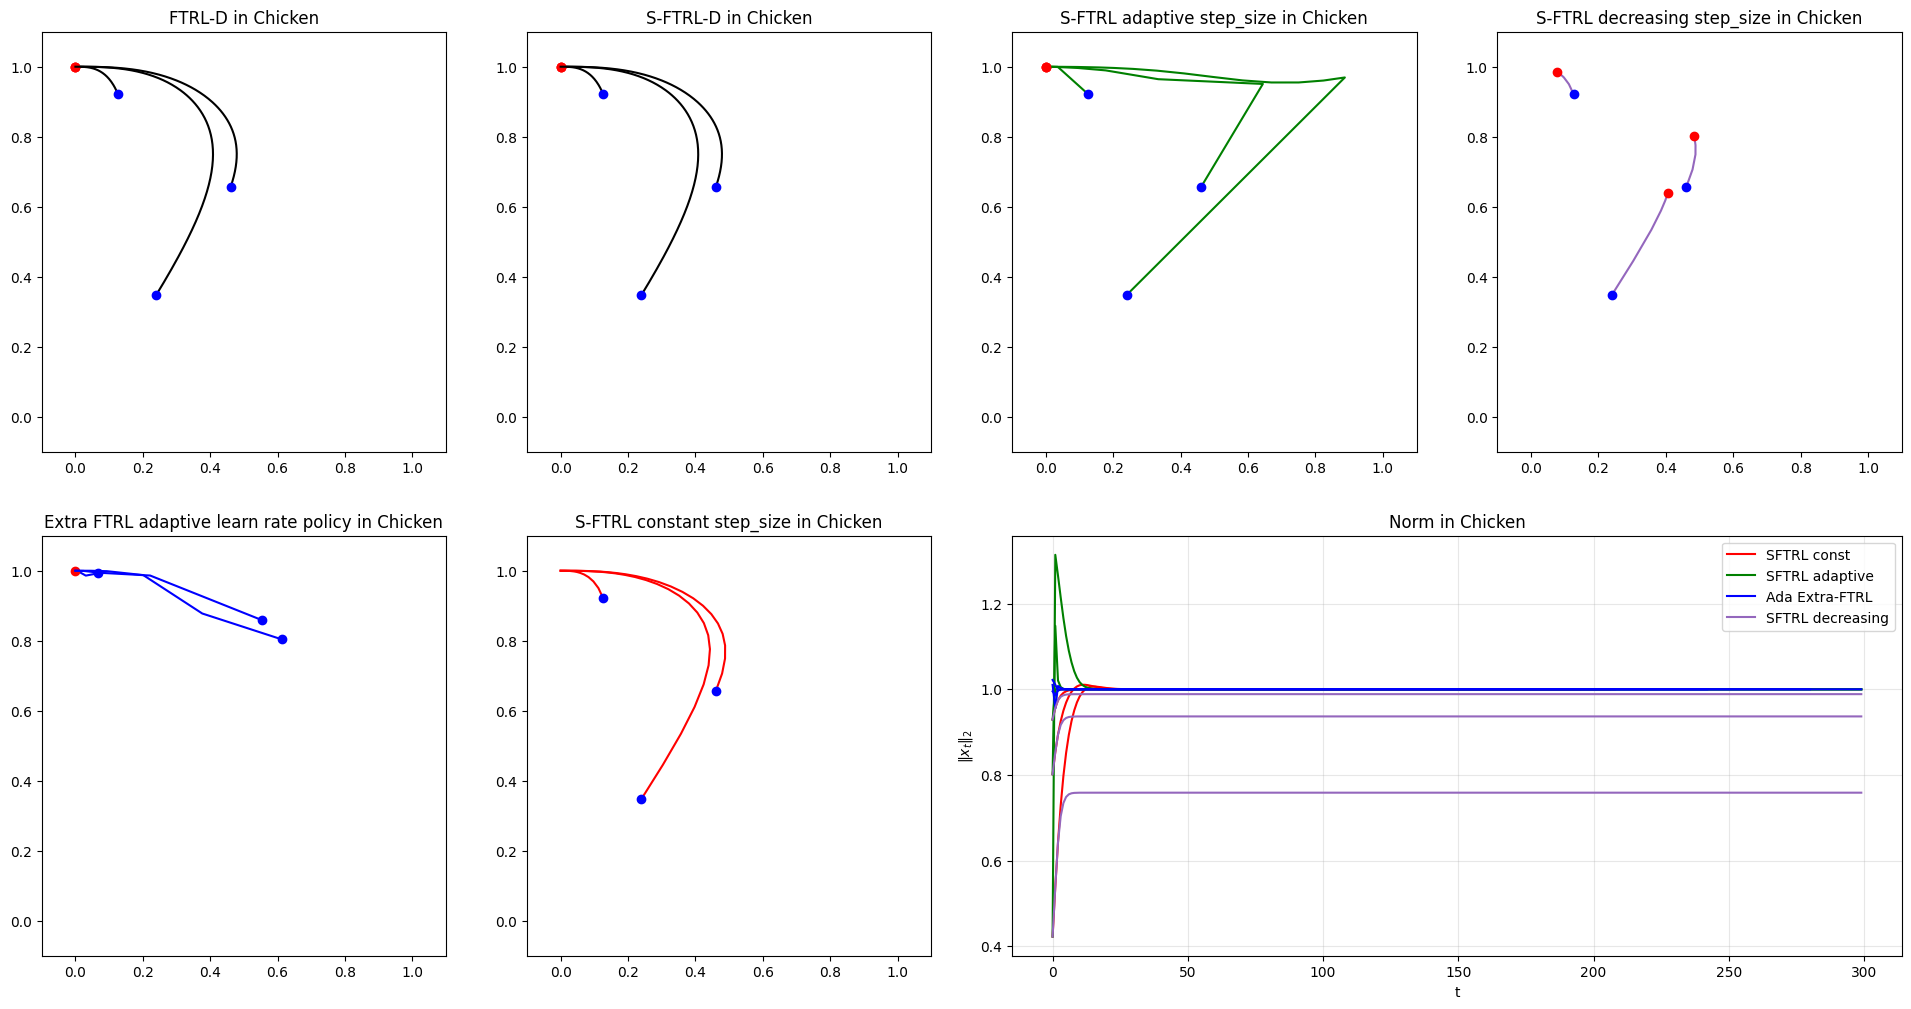

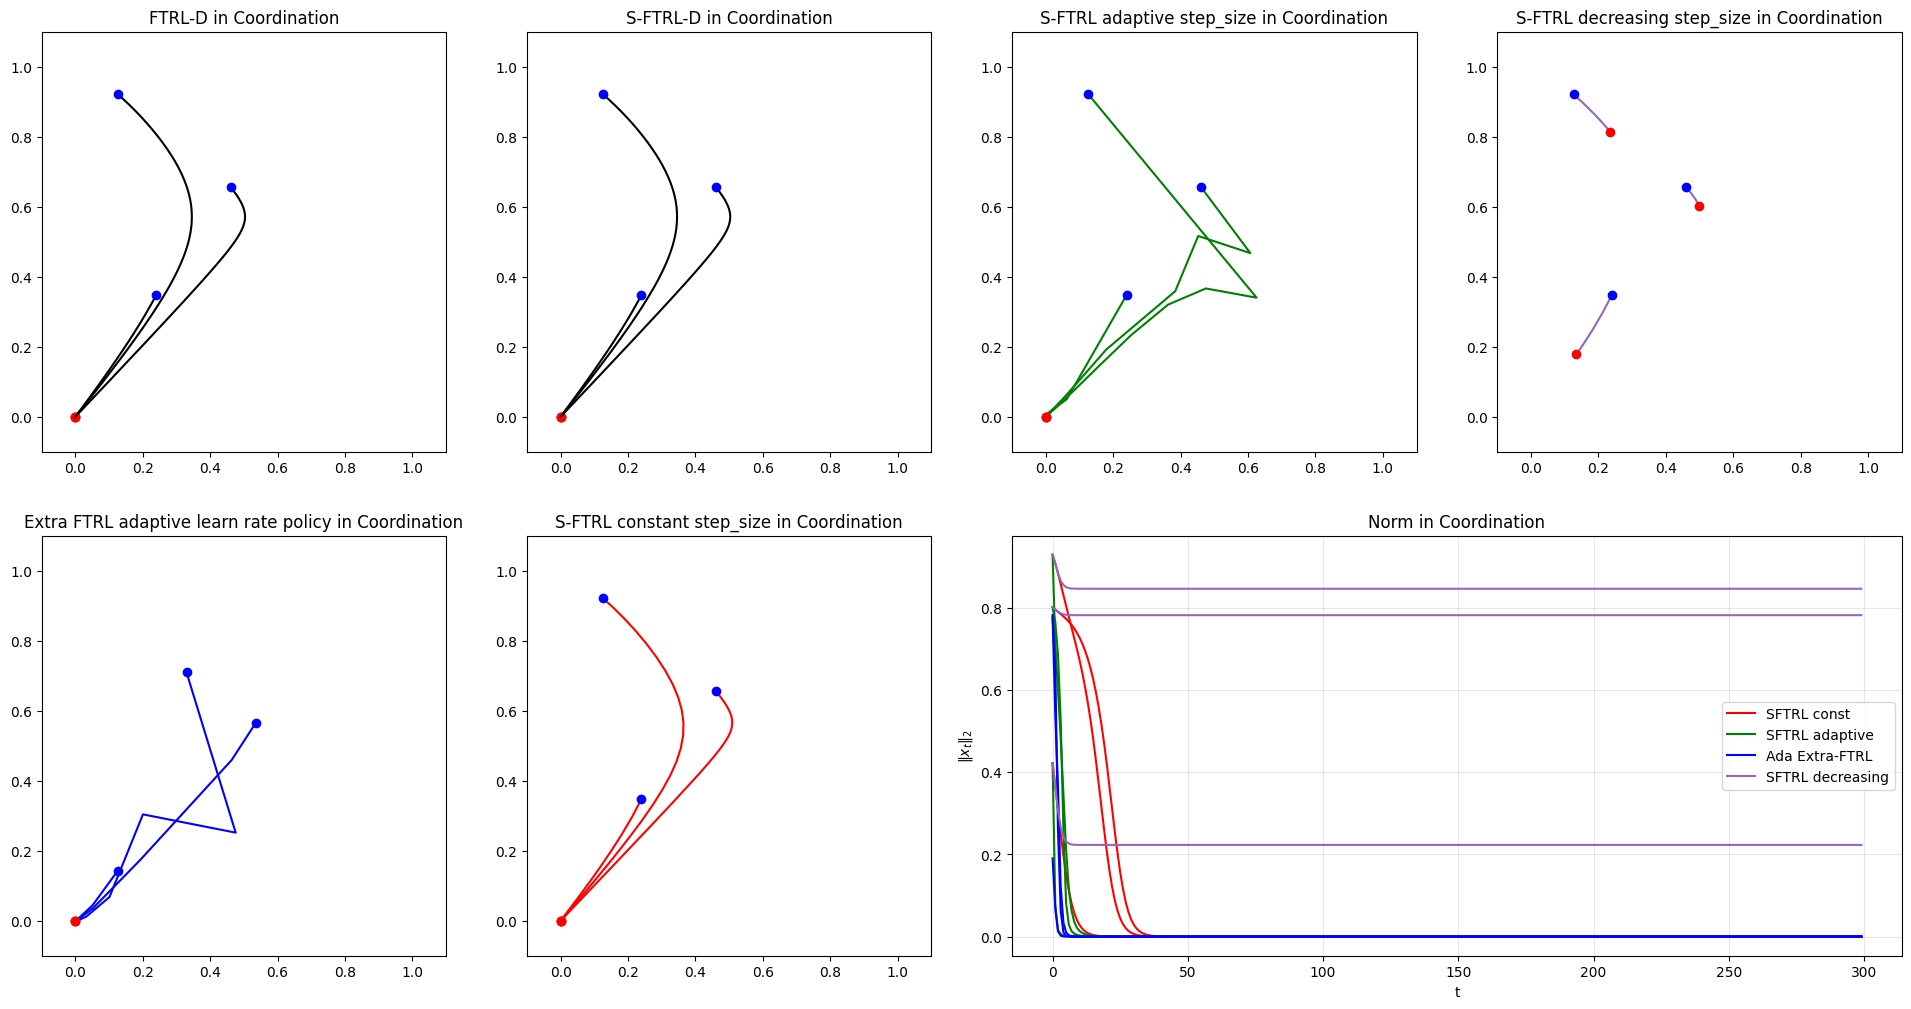

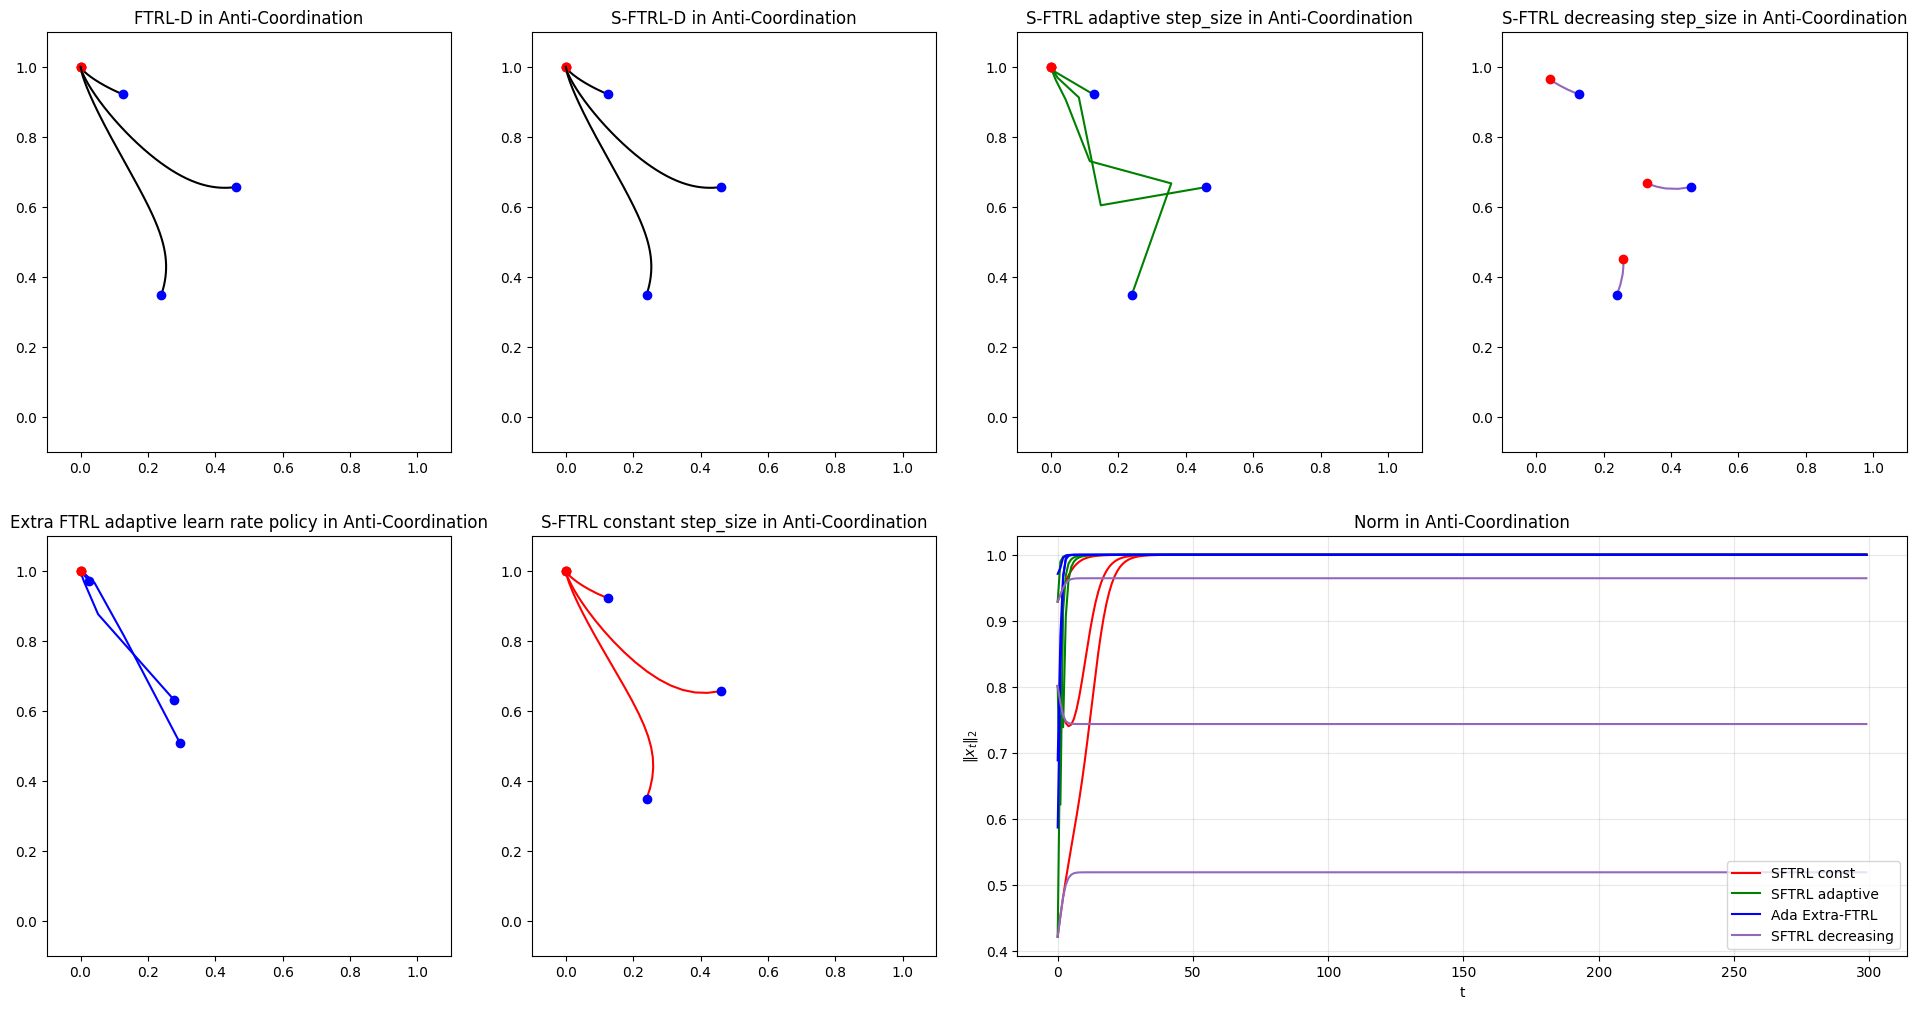

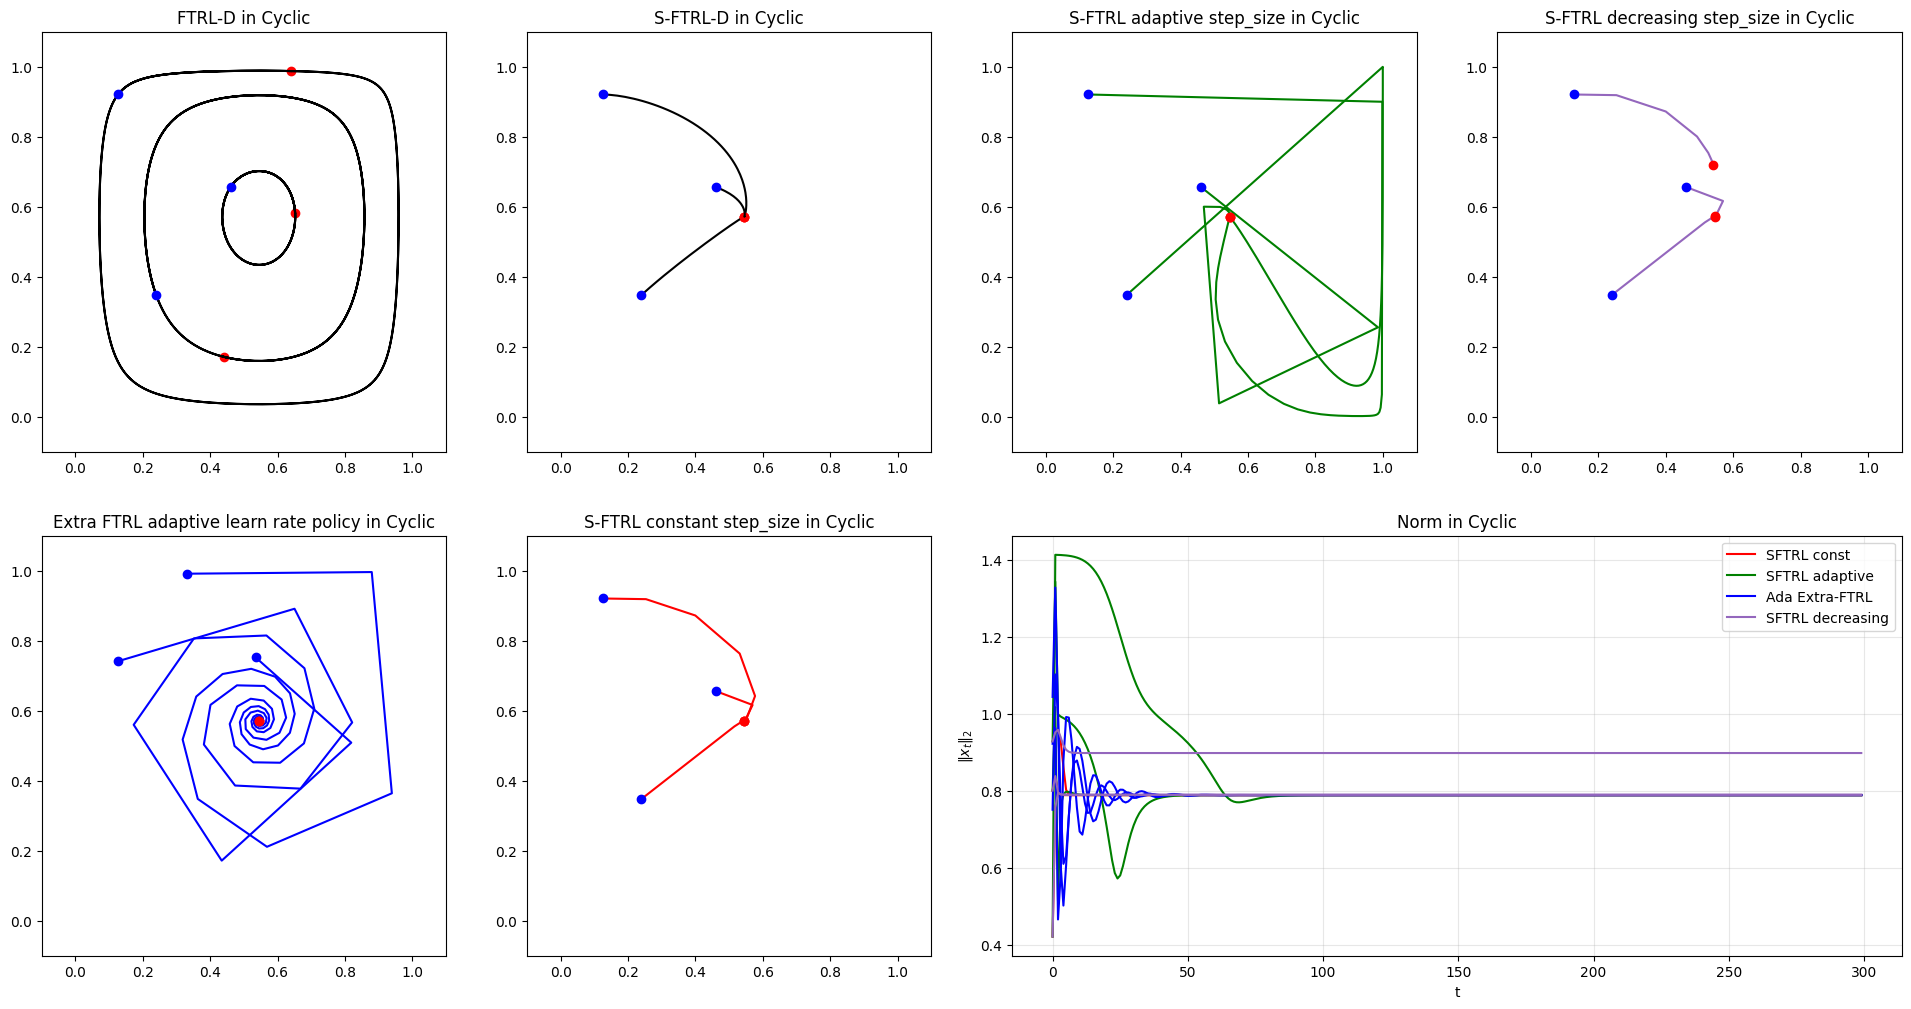

In [75]:
# X effective

import matplotlib.gridspec as gridspec




for i, game in enumerate(eff_ZSFTRL_GAMES):
    
    SFTRL_list, ADA_SFTRL_list, ADA_EXTRA_list, dec_SFTRL_list = [], [], [], []

    fig = plt.figure(figsize = (24,12))
    
    ax1 = fig.add_subplot(2, 4, 1)
    ax2 = fig.add_subplot(2, 4, 2)
    ax3 = fig.add_subplot(2, 4, 3)
    ax4 = fig.add_subplot(2, 4, 4)
    ax5 = fig.add_subplot(2, 4, 5)
    ax6 = fig.add_subplot(2, 4, 6)
    # Distance plot spans last two columns of second row
    gs = fig.add_gridspec(2, 4)
    ax_dist = fig.add_subplot(gs[1, 2:4])

    
    ## ------------------------------------------------
    # ODE
    ## ------------------------------------------------
    for z0 in initial_eff_quot_points[:5]:

        # ODE vanilla
        eff_quot_points = odeint(game.geom_sftrl_dyn, z0, time, args = (0,))
        plot_effZmethod_only_primal(ax1, eff_quot_points, game)
        ax1.set_title(f'FTRL-D in {game.name}')
        
        # ODE symplectic
        corrected_eff_quot_points = odeint(game.geom_sftrl_dyn, z0, time, args = (LAM,))
        plot_effZmethod_only_primal(ax2, corrected_eff_quot_points, game)
        ax2.set_title(f'S-FTRL-D in {game.name}')

    ## ------------------------------------------------
    # ALGO
    ## ------------------------------------------------

    
    
    for z0 in initial_eff_quot_points:
        
        ## ------------------------------------------------
        # Symplectic algo - adaptive step size
        eta_policy = "adaptive"
        ADA_SFTRL_step_size = Ada_SFTRL_step_size(z_1 = np.array(z0), nRuns = N_RUNS, eta_1 = 1, game = game, eta_policy = eta_policy)
        ADA_SFTRL_list.append(ADA_SFTRL_step_size)
        
        ax3.plot(*ADA_SFTRL_step_size, S_ADA_COLOR)
        ax3.plot(ADA_SFTRL_step_size[0][0], ADA_SFTRL_step_size[1][0], 'bo', label = 'initial')
        ax3.plot(ADA_SFTRL_step_size[0][-1], ADA_SFTRL_step_size[1][-1], 'ro', label = 'final')
        ax3.set_xlim(-0.1,1.1)
        ax3.set_ylim(-0.1,1.1)
        ax3.set_title(f'S-FTRL {eta_policy} step_size in {game.name}')

        ## ------------------------------------------------
        # Symplectic algo - constant step size
        eta_policy = "constant"
        SFTRL_step_size = Ada_SFTRL_step_size(z_1 = np.array(z0), nRuns = N_RUNS, eta_1 = 0.1, game = game, eta_policy = eta_policy)
        SFTRL_list.append(SFTRL_step_size)
        
        ax6.plot(*SFTRL_step_size, S_CONST_COLOR)
        ax6.plot(SFTRL_step_size[0][0], SFTRL_step_size[1][0], 'bo', label = 'initial')
        ax6.plot(SFTRL_step_size[0][-1], SFTRL_step_size[1][-1], 'ro', label = 'final')
        ax6.set_xlim(-0.1,1.1)
        ax6.set_ylim(-0.1,1.1)
        ax6.set_title(f'S-FTRL {eta_policy} step_size in {game.name}')

        ## ------------------------------------------------
        # NOT GOOD Adaptive Symplectic algo - learn rate
        ## ------------------------------------------------
        #ADA_SFTRL_learn_rate = Ada_SFTRL_learn_rate(z_1 = np.array(z0), nRuns = 1000, eta_1 = 1, game = game)
        
        #ax4.plot(*ADA_SFTRL_learn_rate, 'k')
        #ax4.plot(ADA_SFTRL_learn_rate[0][0], ADA_SFTRL_learn_rate[1][0], 'bo', label = 'initial')
        #ax4.plot(ADA_SFTRL_learn_rate[0][-1], ADA_SFTRL_learn_rate[1][-1], 'ro', label = 'final')
        #ax4.set_xlim(-0.1,1.1)
        #ax4.set_ylim(-0.1,1.1)
        #ax4.set_title(f'NOT GOOD - Ada S-FTRL learn_rate algo in {game.name}')

        ## ------------------------------------------------
        # Symplectic algo - decreasing step size
        eta_policy = "decreasing"
        dec_SFTRL_step_size = Ada_SFTRL_step_size(z_1 = np.array(z0), nRuns = N_RUNS, eta_1 = 0.1, game = game, eta_policy = eta_policy)
        dec_SFTRL_list.append(dec_SFTRL_step_size)
        
        ax4.plot(*dec_SFTRL_step_size, S_DEC_COLOR)
        ax4.plot(dec_SFTRL_step_size[0][0], dec_SFTRL_step_size[1][0], 'bo', label = 'initial')
        ax4.plot(dec_SFTRL_step_size[0][-1], dec_SFTRL_step_size[1][-1], 'ro', label = 'final')
        ax4.set_xlim(-0.1,1.1)
        ax4.set_ylim(-0.1,1.1)
        ax4.set_title(f'S-FTRL {eta_policy} step_size in {game.name}')

    
        ## ------------------------------------------------
        # Adaptive Extrapolation algo (as in COLT)
        ## ------------------------------------------------
        ADA_EXTRA_FTRL = adaFTRLplus(y_1 = np.array(z0), nRuns = N_RUNS, lam_payfield = lam_payfields[i], eta_1 = np.ones(2), v_half = np.zeros(2),  coef = 0.5 * np.ones(2) )
        ADA_EXTRA_list.append(ADA_EXTRA_FTRL)
        ax5.plot(*ADA_EXTRA_FTRL, EXTRA_ADA_COLOR)
        ax5.plot(ADA_EXTRA_FTRL[0][0], ADA_EXTRA_FTRL[1][0], 'bo', label = 'initial')
        ax5.plot(ADA_EXTRA_FTRL[0][-1], ADA_EXTRA_FTRL[1][-1], 'ro', label = 'final')
        ax5.set_xlim(-0.1,1.1)
        ax5.set_ylim(-0.1,1.1)
        ax5.set_title(f'Extra FTRL adaptive learn rate policy in {game.name}')
        
        ## ------------------------------------------------


   
    for enum_obj, label, color in [  (enumerate(SFTRL_list), "SFTRL const", S_CONST_COLOR), 
                                     (enumerate(ADA_SFTRL_list), "SFTRL adaptive", S_ADA_COLOR), 
                                     (enumerate(ADA_EXTRA_list), "Ada Extra-FTRL", EXTRA_ADA_COLOR),
                                     (enumerate(dec_SFTRL_list), "SFTRL decreasing", S_DEC_COLOR) 
                           ]:
        for j, traj in enum_obj:
            norm_traj = norm(traj)
            if j == 0:
                ax_dist.plot(HORIZON, norm_traj, label = label, color = color)
            else:
                ax_dist.plot(HORIZON, norm_traj, color = color)
        
        ax_dist.set_title(f"Norm in {game.name}")
        ax_dist.set_xlabel("t")
        ax_dist.set_ylabel(r"$\|x_t\|_2$")
        ax_dist.legend()
        ax_dist.grid(alpha=0.3)
    #
    plt.savefig(f'figures/{game.name}.pdf')



    
    
        

#plt.legend(loc = 'best')
plt.show()
        
    #plt.xlim(0,1)
    #plt.ylim(0,1)
    
   


## Overall, symplectic FTRL with CONSTANT step size seems well-behaved and offers performances comparable to those of AdaExtraFTRL; adaptive policy out-of-the-box does not seem to work for symplectic FTRL.
- do regret and converhence analysis for constant step size
- see if can come up with compatible adaptive policy
- long term, imperfect info: estimate first- and second- order signals